Streamlit App link: http://10.7.41.113:8501

In [1]:
# Library imports
import os
import re
import random
import json
import math
import time
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from tqdm import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Hardware setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("DEVICE:", device)

DEVICE: cuda


##  Preprocessing and Vocabulary Construction

In [2]:
# Data directory setup
DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# URLs for the datasets
urls = {
    "sherlock": "https://www.gutenberg.org/files/1661/1661-0.txt",                  # Sherlock Holmes text
    "linux_code": "https://cs.stanford.edu/people/karpathy/char-rnn/linux.txt"      # Linux kernel code (alternative: https://norvig.com/ngrams/linux_input.txt)
}

# Local file paths
catI_path = DATA_DIR / "sherlock.txt"
catII_path = DATA_DIR / "linux.txt"

# Download helper function
import requests
from requests.exceptions import RequestException
from tqdm import tqdm

def download_if_missing(url, dest_path, chunk_size=1024):
    dest_path = Path(dest_path)
    if dest_path.exists():
        print(f"{dest_path} already exists -> skipping download.")
        return dest_path
    dest_path.parent.mkdir(parents=True, exist_ok=True)
    try:
        with requests.get(url, stream=True, timeout=30) as r:
            r.raise_for_status()
            total = int(r.headers.get('content-length', 0))
            with open(dest_path, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True, desc=dest_path.name) as pbar:
                for chunk in r.iter_content(chunk_size=chunk_size):
                    if chunk:
                        f.write(chunk)
                        pbar.update(len(chunk))
        print(f"Downloaded {dest_path}")
        return dest_path
    except RequestException as e:
        if dest_path.exists():
            print(f"Warning: download incomplete but file exists: {dest_path}")
            return dest_path
        raise RuntimeError(f"Failed to download {url}: {e}")

# Attempt download if files not present
download_if_missing(urls["sherlock"], catI_path)
download_if_missing(urls["linux_code"], catII_path)

sherlock.txt: 100%|██████████| 608k/608k [00:00<00:00, 807kB/s] 


Downloaded data/sherlock.txt


linux.txt: 1.00MB [00:00, 1.82MB/s]

Downloaded data/linux.txt


PosixPath('data/linux.txt')

In [4]:
def preprocess_natural_text(filepath):
    with open(filepath, encoding='utf-8') as f:
        sample_text = f.read()
    sample_text = sample_text.lower().replace('.', ' . ')
    # Remove everything except letters, numbers, dots, spaces, and newlines
    clean_text = re.sub(r'[^a-zA-Z0-9 \.\n]', '', sample_text)
    # Mark sentence starts
    clean_text = re.sub(r'\n+', '\n<start> ', clean_text)
    # Collapse multiple spaces to a single space
    clean_text = re.sub(r'[ \t]+', ' ', clean_text)
    # Split by newlines and remove empty/short segments
    sentences = [s.strip() for s in clean_text.split('\n') if s.strip() and len(s.strip()) > 10]
    return sentences

# Usage
raw_natural = preprocess_natural_text(catI_path)
print("Preview Natural Language:", raw_natural[:20])

Preview Natural Language: ['the project gutenberg ebook of the adventures of sherlock holmes', '<start> by arthur conan doyle', '<start> this ebook is for the use of anyone anywhere in the united states and', '<start> most other parts of the world at no cost and with almost no restrictions', '<start> whatsoever . you may copy it give it away or reuse it under the terms', '<start> of the project gutenberg license included with this ebook or online at', '<start> www . gutenberg . org . if you are not located in the united states you', '<start> will have to check the laws of the country where you are located before', '<start> using this ebook .', '<start> title the adventures of sherlock holmes', '<start> author arthur conan doyle', '<start> release date november 29 2002 ebook 1661', '<start> most recently updated october 10 2023', '<start> language english', '<start> character set encoding utf8', '<start> produced by an anonymous project gutenberg volunteer and jose menendez', '<start> s

In [5]:
def preprocess_code_text(filepath):
    try:
        with open(filepath, encoding='utf-8', errors='replace') as f:
            text = f.read()
    except UnicodeDecodeError:
        with open(filepath, encoding='latin1') as f:
            text = f.read()
    statements = [stmt.strip() for stmt in text.split('\n') if stmt.strip() and len(stmt.strip()) > 5]
    code_text = ' '.join(statements)
    # Space out symbols/operators
    code_text = re.sub('([^A-Za-z0-9\s])', r' \1 ', code_text)
    code_text = re.sub(r'\s+', ' ', code_text)  # Collapse spaces
    return code_text

# Usage
raw_code = preprocess_code_text(catII_path)
print("Preview Structured/Code:", raw_code[:300])


Preview Structured/Code: static void start _ ctrl _ regs _ pc _ filter ( struct function * feature , struct fuse _ ctrl * p _ ctr , unsigned int cur _ ctrl , unsigned int dfl _ sched _ ok ) struct fuse _ ctr * ctrl ; int enabled ; ctrl = firmware - > fsr ; false = false ; if ( ( media _ entities - > type & FUSE _ TYPE _ CCR


In [6]:
def build_vocabulary(text, add_special_tokens=True):
    # Tokenize by splitting on space
    words = text.split()
    counter = Counter(words)
    vocab = sorted(counter.keys())
    if add_special_tokens:
        vocab = ['<PAD>', '<UNK>'] + vocab  # Add padding & unknown tokens if needed

    # Mappings: stoi (string to index), itos (index to string)
    stoi = {word: idx for idx, word in enumerate(vocab)}
    itos = {idx: word for word, idx in stoi.items()}
    vocab_size = len(vocab)
    return stoi, itos, vocab_size, counter

# Apply to both datasets
natural_text_str = ' '.join(raw_natural)
stoi_natural, itos_natural, vocab_size_natural, freq_natural = build_vocabulary(natural_text_str)
stoi_code, itos_code, vocab_size_code, freq_code = build_vocabulary(raw_code)

print("Natural language vocab size:", vocab_size_natural)
print("Code vocab size:", vocab_size_code)

# Show stats: most/least frequent
print("\nNatural language - 10 most frequent words:\n", freq_natural.most_common(10))
print("Natural language - 10 least frequent words:\n", freq_natural.most_common()[-10:])

print("\nCode - 10 most frequent words:\n", freq_code.most_common(10))
print("Code - 10 least frequent words:\n", freq_code.most_common()[-10:])


Natural language vocab size: 8687
Code vocab size: 15562

Natural language - 10 most frequent words:
 [('<start>', 9622), ('.', 6431), ('the', 5811), ('and', 3066), ('i', 2994), ('of', 2779), ('to', 2763), ('a', 2683), ('in', 1818), ('that', 1750)]
Natural language - 10 least frequent words:
 [('michael', 1), ('hart', 1), ('originator', 1), ('network', 1), ('necessarily', 1), ('edition', 1), ('pg', 1), ('includes', 1), ('subscribe', 1), ('newsletter', 1)]

Code - 10 most frequent words:
 [('_', 40541), (';', 15464), ('(', 14219), (')', 14194), ('*', 10723), (',', 9952), ('-', 8981), ('=', 8471), ('>', 7352), ('&', 4393)]
Code - 10 least frequent words:
 [('sortlib', 1), ('delig', 1), ('Calculate', 1), ('dsis', 1), ('udphdr', 1), ('getdesc', 1), ('fwd', 1), ('pays', 1), ('serveraddr', 1), ('int1', 1)]


In [7]:
def create_context_target_pairs(words, stoi, block_size=3):
    """
    Given a list of words, create context-target pairs for next-word prediction.
    - context: previous block_size words (as indices)
    - target: next word (as index)
    """
    X, y = [], []
    for i in range(len(words) - block_size):
        context = words[i:i+block_size]
        target = words[i+block_size]
        # Map words to indices, use <UNK> index for unknowns (should not happen here)
        context_idx = [stoi.get(w, stoi['<UNK>']) for w in context]
        target_idx = stoi.get(target, stoi['<UNK>'])
        X.append(context_idx)
        y.append(target_idx)
    return np.array(X), np.array(y)

# Tokenize preprocessed text
words_natural = natural_text_str.split()
words_code = raw_code.split()

block_size = 3

# Create training data
X_natural, y_natural = create_context_target_pairs(words_natural, stoi_natural, block_size)
X_code, y_code = create_context_target_pairs(words_code, stoi_code, block_size)

print("Natural language X shape:", X_natural.shape, "y shape:", y_natural.shape)
print("Code X shape:", X_code.shape, "y shape:", y_code.shape)

# Inspect some samples
for i in range(3):
    print("Natural example:", [itos_natural[ix] for ix in X_natural[i]], "->", itos_natural[y_natural[i]])
    print("Code example:", [itos_code[ix] for ix in X_code[i]], "->", itos_code[y_code[i]])


Natural language X shape: (123653, 3) y shape: (123653,)
Code X shape: (310031, 3) y shape: (310031,)
Natural example: ['the', 'project', 'gutenberg'] -> ebook
Code example: ['static', 'void', 'start'] -> _
Natural example: ['project', 'gutenberg', 'ebook'] -> of
Code example: ['void', 'start', '_'] -> ctrl
Natural example: ['gutenberg', 'ebook', 'of'] -> the
Code example: ['start', '_', 'ctrl'] -> _


## Model Design and Training

In [7]:
class NextWordMLP(nn.Module):
    def __init__(self, vocab_size, block_size, embedding_dim=32, hidden_dim=1024, num_hidden_layers=2, activation='relu'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        input_dim = embedding_dim * block_size

        layers = []
        for i in range(num_hidden_layers):
            layers.append(nn.Linear(input_dim if i == 0 else hidden_dim, hidden_dim))
            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'tanh':
                layers.append(nn.Tanh())
            else:
                raise ValueError("Unknown activation type")
        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        # x: (batch_size, block_size)
        embeds = self.embedding(x)                     # (batch_size, block_size, embedding_dim)
        flat = embeds.view(embeds.size(0), -1)         # (batch_size, block_size*embedding_dim)
        features = self.mlp(flat)                      # (batch_size, hidden_dim)
        logits = self.classifier(features)             # (batch_size, vocab_size)
        return logits

In [8]:
from torch.utils.data import TensorDataset, DataLoader, random_split

def create_dataloaders(X, y, val_frac=0.2, batch_size=1024):
    # Convert to tensors
    Xtensor = torch.tensor(X, dtype=torch.long)
    ytensor = torch.tensor(y, dtype=torch.long)
    dataset = TensorDataset(Xtensor, ytensor)
    # Split into train and val
    val_size = int(len(dataset) * val_frac)
    train_size = len(dataset) - val_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)
    return train_loader, val_loader

batch_size = 1024

train_loader_natural, val_loader_natural = create_dataloaders(X_natural, y_natural, val_frac=0.2, batch_size=batch_size)
train_loader_code, val_loader_code = create_dataloaders(X_code, y_code, val_frac=0.2, batch_size=batch_size)


In [9]:
def train_mlp(model, train_loader, val_loader, epochs=500, lr=1e-6, patience=10, device='cpu'):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loss_history, val_loss_history, val_acc_history = [], [], []
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(1, epochs+1):
        model.train()
        train_loss = 0
        for Xbatch, ybatch in train_loader:
            Xbatch, ybatch = Xbatch.to(device), ybatch.to(device)
            optimizer.zero_grad()
            output = model(Xbatch)
            loss = criterion(output, ybatch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * Xbatch.size(0)
        train_loss /= len(train_loader.dataset)
        train_loss_history.append(train_loss)

        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for Xbatch, ybatch in val_loader:
                Xbatch, ybatch = Xbatch.to(device), ybatch.to(device)
                output = model(Xbatch)
                loss = criterion(output, ybatch)
                val_loss += loss.item() * Xbatch.size(0)
                
                _, predicted = torch.max(output, dim=1)
                correct += (predicted == ybatch).sum().item()
                total += ybatch.size(0)
        val_loss /= len(val_loader.dataset)
        val_loss_history.append(val_loss)
        val_acc = 100. * correct / total
        val_acc_history.append(val_acc)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.2f}%")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}. Best val loss: {best_val_loss:.4f}")
            model.load_state_dict(best_model_state)
            break

    return train_loss_history, val_loss_history, val_acc_history, best_model_state

## For Category-I

In [10]:
embedding_dims = [32, 64]
hidden_dims = [1024]          # You can expand to list
num_hidden_layers_list = [1, 2]
activations = ['relu', 'tanh']
context_length = 3
results_natural = {}

for emb_dim in embedding_dims:
    for hidden_dim in hidden_dims:
        for num_hidden_layers in num_hidden_layers_list:
            for activation in activations:
                config_str = f"emb{emb_dim}_hidden{hidden_dim}_layers{num_hidden_layers}_{activation}"
                model = NextWordMLP(
                    vocab_size=len(stoi_natural),
                    block_size=context_length,
                    embedding_dim=emb_dim,
                    hidden_dim=hidden_dim,
                    num_hidden_layers=num_hidden_layers,
                    activation=activation
                )
                print(f"\nTraining {config_str}...")
                train_losses, val_losses, val_accuracies, best_model_state = train_mlp(
                    model, train_loader_natural, val_loader_natural, epochs=500, lr=1e-5, patience=10, device=device
                )
                # Save the best model for this hyperparameter combo
                torch.save({
                    'model_state_dict': best_model_state,
                    'train_losses': train_losses,
                    'val_losses': val_losses,
                    'val_accuracies': val_accuracies,
                    'hyperparams': {
                        'emb_dim': emb_dim,
                        'hidden_dim': hidden_dim,
                        'num_hidden_layers': num_hidden_layers,
                        'activation': activation,
                        'context_length': context_length
                    }
                }, f'{config_str}_natural.pth')
                # save stats for later summary
                results_natural[config_str] = {
                    'train_losses': train_losses,
                    'val_losses': val_losses,
                    'val_accuracies': val_accuracies
                }



Training emb32_hidden1024_layers1_relu...
Epoch 1 | Train Loss: 8.9985 | Val Loss: 8.8682 | Val Accuracy: 0.14%
Epoch 10 | Train Loss: 6.7514 | Val Loss: 6.7940 | Val Accuracy: 6.30%
Epoch 20 | Train Loss: 5.8498 | Val Loss: 6.1031 | Val Accuracy: 9.43%
Epoch 30 | Train Loss: 5.6360 | Val Loss: 5.9897 | Val Accuracy: 9.97%
Epoch 40 | Train Loss: 5.4739 | Val Loss: 5.9257 | Val Accuracy: 10.55%
Epoch 50 | Train Loss: 5.3320 | Val Loss: 5.8871 | Val Accuracy: 11.01%
Epoch 60 | Train Loss: 5.1998 | Val Loss: 5.8647 | Val Accuracy: 11.42%
Epoch 70 | Train Loss: 5.0725 | Val Loss: 5.8541 | Val Accuracy: 11.70%
Epoch 80 | Train Loss: 4.9482 | Val Loss: 5.8538 | Val Accuracy: 12.16%
Early stopping at epoch 85. Best val loss: 5.8528

Training emb32_hidden1024_layers1_tanh...
Epoch 1 | Train Loss: 9.0628 | Val Loss: 9.0249 | Val Accuracy: 0.06%
Epoch 10 | Train Loss: 8.1310 | Val Loss: 8.1577 | Val Accuracy: 7.08%
Epoch 20 | Train Loss: 6.9214 | Val Loss: 7.0949 | Val Accuracy: 8.73%
Epoch 30 

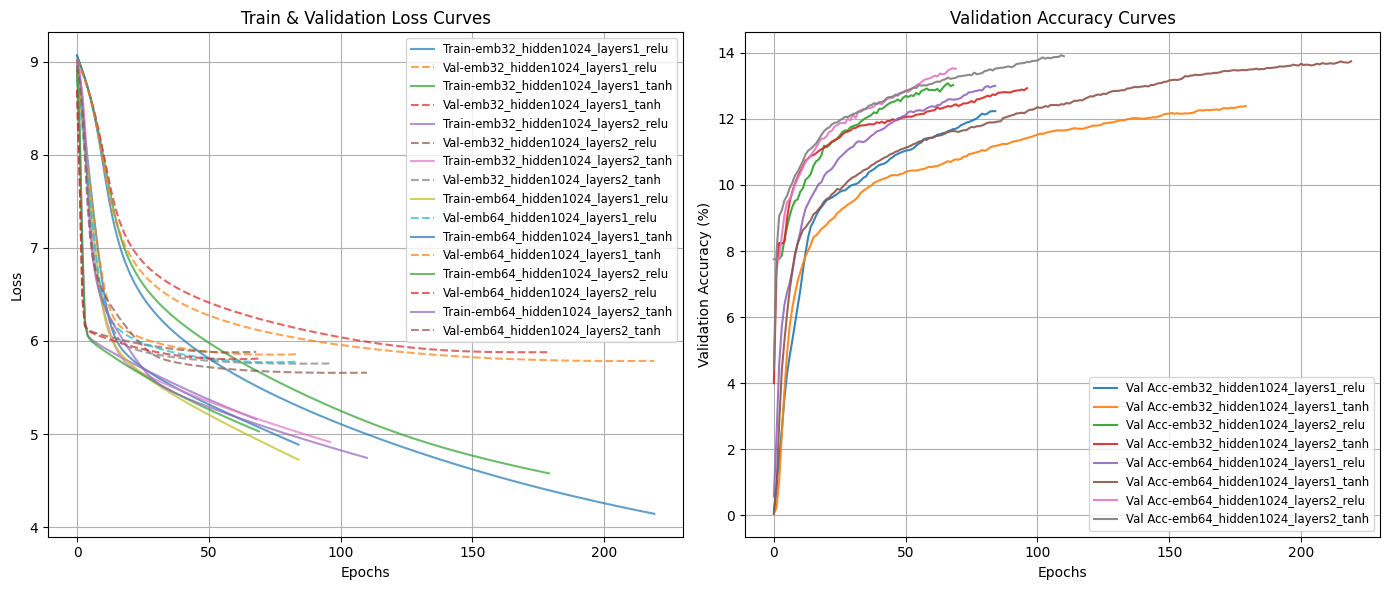

In [25]:
def plot_metrics(results):
    plt.figure(figsize=(14, 6))
    
    # Plot Loss curves
    plt.subplot(1, 2, 1)
    for config, stats in results.items():
        label = config   # just use the config string
        plt.plot(stats['train_losses'], label=f"Train-{label}", alpha=0.7, linestyle='-')
        plt.plot(stats['val_losses'], label=f"Val-{label}", alpha=0.7, linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Train & Validation Loss Curves")
    plt.legend(fontsize='small', loc='upper right')
    plt.grid()

    # Plot Accuracy curves
    plt.subplot(1, 2, 2)
    for config, stats in results.items():
        label = config
        plt.plot(stats['val_accuracies'], label=f"Val Acc-{label}", alpha=0.9)
    plt.xlabel("Epochs")
    plt.ylabel("Validation Accuracy (%)")
    plt.title("Validation Accuracy Curves")
    plt.legend(fontsize='small', loc='lower right')
    plt.grid()

    plt.tight_layout()
    plt.show()

# Usage after training (for natural):
plot_metrics(results_natural)

In [27]:
summary = []
for config, stats in results_natural.items():
    # Parse config string, e.g., "emb32_hidden1024_layers2_relu"
    m = re.match(r'emb(\d+)_hidden(\d+)_layers(\d+)_(\w+)', config)
    if m:
        emb_dim, hidden_dim, num_layers, act = m.groups()
    else:
        emb_dim, hidden_dim, num_layers, act = [None]*4

    val_loss_min = min(stats['val_losses'])
    best_epoch = stats['val_losses'].index(val_loss_min) + 1
    best_val_acc = stats['val_accuracies'][best_epoch-1]
    summary.append({
        "embedding_dim": int(emb_dim) if emb_dim else None,
        "hidden_dim": int(hidden_dim) if hidden_dim else None,
        "num_hidden_layers": int(num_layers) if num_layers else None,
        "activation": act,
        "best_val_loss": val_loss_min,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "config_label": config
    })

df_summary = pd.DataFrame(summary)
df_sorted = df_summary.sort_values("best_val_acc", ascending=False)
print(df_sorted)

   embedding_dim  hidden_dim  num_hidden_layers activation  best_val_loss  \
7             64        1024                  2       tanh       5.657148   
5             64        1024                  1       tanh       5.784226   
6             64        1024                  2       relu       5.803809   
2             32        1024                  2       relu       5.878331   
4             64        1024                  1       relu       5.771453   
3             32        1024                  2       tanh       5.755928   
1             32        1024                  1       tanh       5.878412   
0             32        1024                  1       relu       5.852783   

   best_val_acc  best_epoch                   config_label  
7     13.768702         101  emb64_hidden1024_layers2_tanh  
5     13.671654         210  emb64_hidden1024_layers1_tanh  
6     13.226850          60  emb64_hidden1024_layers2_relu  
2     12.919531          59  emb32_hidden1024_layers2_relu  
4

In [28]:
config_str = "emb64_hidden1024_layers1_tanh"   # Example, use your best config
checkpoint = torch.load(f"{config_str}_natural.pth")
model_best = NextWordMLP(
    vocab_size=len(stoi_natural),
    block_size=context_length,
    embedding_dim=64,     
    hidden_dim=1024,      
    num_hidden_layers=1,  
    activation='tanh'     
)
model_best.load_state_dict(checkpoint['model_state_dict'])
model_best.to(device)

NextWordMLP(
  (embedding): Embedding(8687, 64)
  (mlp): Sequential(
    (0): Linear(in_features=192, out_features=1024, bias=True)
    (1): Tanh()
  )
  (classifier): Linear(in_features=1024, out_features=8687, bias=True)
)

In [29]:
def predict_top_k_words(model, context_words, stoi, itos, block_size, k=5, device='cpu'):
    context_idx = [stoi.get(w, stoi['<UNK>']) for w in context_words[-block_size:]]
    if len(context_idx) < block_size:
        context_idx = [stoi['<PAD>']] * (block_size - len(context_idx)) + context_idx
    x = torch.tensor(context_idx, dtype=torch.long).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    top_indices = probs.argsort()[-k:][::-1]
    return [(itos[i], probs[i]) for i in top_indices]

# Use context_length for block_size and your user dataset
sample_contexts = [
    ["the", "adventure", "of", "the"],
    ["sherlock", "holmes", "was"],
    ["watson", "looked", "at"],
    ["today", "the", "weather"],
    ["it", "might", "rain"]
]

for context in sample_contexts:
    top_words = predict_top_k_words(model_best, context, stoi_natural, itos_natural, context_length, k=5, device=device)
    print(f"Context: {context} --> Top 5 predicted: {top_words}")

Context: ['the', 'adventure', 'of', 'the'] --> Top 5 predicted: [('beryl', 0.089059524), ('<start>', 0.08862247), ('house', 0.023169296), ('blue', 0.022396268), ('speckled', 0.019794073)]
Context: ['sherlock', 'holmes', 'was'] --> Top 5 predicted: [('a', 0.14023475), ('<start>', 0.050928988), ('the', 0.038766187), ('.', 0.030184688), ('silent', 0.02970282)]
Context: ['watson', 'looked', 'at'] --> Top 5 predicted: [('the', 0.14959048), ('<start>', 0.08601386), ('a', 0.06457781), ('it', 0.040434077), ('all', 0.037057575)]
Context: ['today', 'the', 'weather'] --> Top 5 predicted: [('of', 0.16030878), ('<start>', 0.12332114), ('.', 0.10556584), ('is', 0.02861585), ('was', 0.021987136)]
Context: ['it', 'might', 'rain'] --> Top 5 predicted: [('<start>', 0.11008136), ('of', 0.043091808), ('.', 0.03012999), ('be', 0.026074652), ('to', 0.017443772)]


The model demonstrates good learning of basic grammatical structure. Given a subject and verb like "watson looked at," it correctly predicts common articles ("the", "a") as the most likely next words. However, for more open-ended contexts like "the adventure of the," its top predictions ("beryl", "<start>") show less creative and semantic understanding, defaulting to a structural token (<start>) or a proper noun ("beryl") that may have appeared in that specific 3-gram context

In [36]:
def plot_embedding_tsne(model, itos, word_freq, top_n=200, perplexity=30, n_iter=1000, seed=42):
    # Get the top-n most frequent words
    most_common = sorted(word_freq.items(), key=lambda x: -x[1])[:top_n]
    words_to_plot = [w for w, f in most_common]
    idxs = [i for i, w in itos.items() if w in words_to_plot]

    emb_weights = model.embedding.weight.detach().cpu().numpy()
    selected = emb_weights[idxs]
    tsne = TSNE(n_components=2, perplexity=min(perplexity, max(5, len(idxs)//3)), n_iter=n_iter, random_state=seed)
    coords = tsne.fit_transform(selected)
    plt.figure(figsize=(10,8))
    for i, (x, y) in enumerate(coords):
        plt.scatter(x, y)
        plt.text(x + 0.3, y + 0.3, itos[idxs[i]], fontsize=9)
    plt.title(f"t-SNE of Top {top_n} Frequent Word Embeddings")
    plt.show()

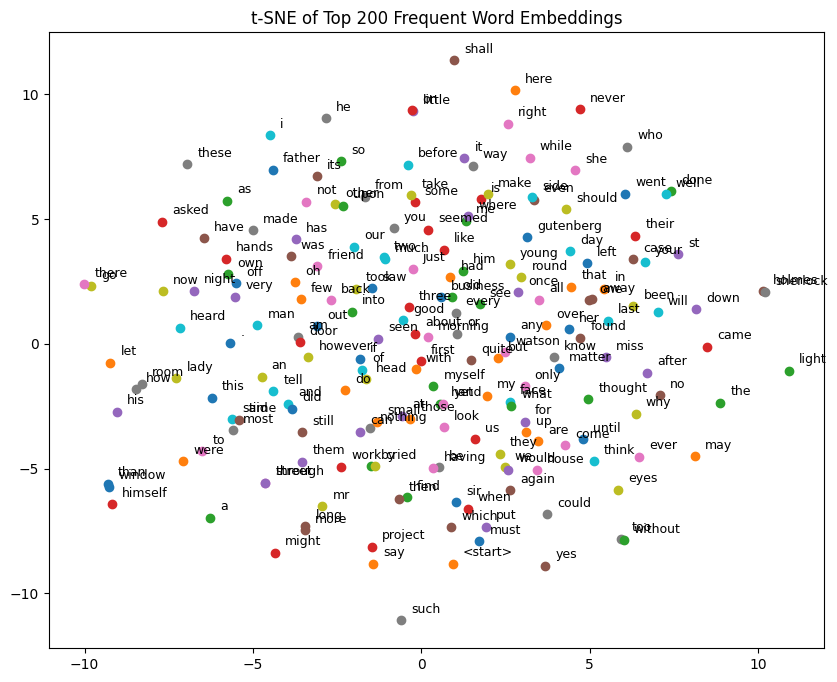

In [33]:
from collections import Counter

# words_natural: tokenized list used to build your dataset
word_freq_natural = Counter(words_natural)
# This creates a dictionary {word: frequency}

# Now you can use it in your plot function:
plot_embedding_tsne(model_best, itos_natural, word_freq_natural, top_n=200, perplexity=20, n_iter=500)


## For Category-II

In [17]:
embedding_dims = [32, 64]
hidden_layer_configs = [
    [1024],
    [1024, 1024],
]
activations = ['relu', 'tanh']
context_length = 3

results_code = {}
for emb_dim in embedding_dims:
    for hidden_dims in hidden_layer_configs:
        num_layers = len(hidden_dims)    # This should always be int
        for act in activations:
            config_str = f"CODE_emb{emb_dim}_hidden{hidden_dims}_layers{num_layers}_{act}"
            model = NextWordMLP(
                vocab_size_code,
                context_length,
                embedding_dim=int(emb_dim),
                hidden_dim=int(hidden_dims[0]),  # assumes uniform dims for all layers
                num_hidden_layers=int(num_layers),
                activation=act
            )
            print(f"\nTraining {config_str}...")
            train_losses, val_losses, val_accuracies, best_model_state = train_mlp(
                model, train_loader_code, val_loader_code, epochs=500, lr=1e-5, patience=10, device=device
            )
            torch.save({
                'model_state_dict': best_model_state,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'val_accuracies': val_accuracies,
                'emb_dim': emb_dim,
                'hidden_dims': hidden_dims,
                'num_layers': num_layers,
                'activation': act
            }, f'{config_str}.pth')
            results_code[config_str] = {
                'train_losses': train_losses,
                'val_losses': val_losses,
                'val_accuracies': val_accuracies
            }



Training CODE_emb32_hidden[1024]_layers1_relu...
Epoch 1 | Train Loss: 9.2497 | Val Loss: 8.8467 | Val Accuracy: 5.97%
Epoch 10 | Train Loss: 4.8960 | Val Loss: 5.0313 | Val Accuracy: 21.17%
Epoch 20 | Train Loss: 4.3699 | Val Loss: 4.6575 | Val Accuracy: 25.58%
Epoch 30 | Train Loss: 4.0942 | Val Loss: 4.5287 | Val Accuracy: 27.82%
Epoch 40 | Train Loss: 3.8944 | Val Loss: 4.4860 | Val Accuracy: 29.18%
Epoch 50 | Train Loss: 3.7297 | Val Loss: 4.4886 | Val Accuracy: 30.13%
Early stopping at epoch 54. Best val loss: 4.4829

Training CODE_emb32_hidden[1024]_layers1_tanh...
Epoch 1 | Train Loss: 9.4984 | Val Loss: 9.3065 | Val Accuracy: 7.33%
Epoch 10 | Train Loss: 5.6015 | Val Loss: 5.6538 | Val Accuracy: 22.52%
Epoch 20 | Train Loss: 4.8153 | Val Loss: 5.0112 | Val Accuracy: 25.19%
Epoch 30 | Train Loss: 4.5106 | Val Loss: 4.7963 | Val Accuracy: 26.79%
Epoch 40 | Train Loss: 4.3074 | Val Loss: 4.6776 | Val Accuracy: 27.72%
Epoch 50 | Train Loss: 4.1490 | Val Loss: 4.6025 | Val Accurac

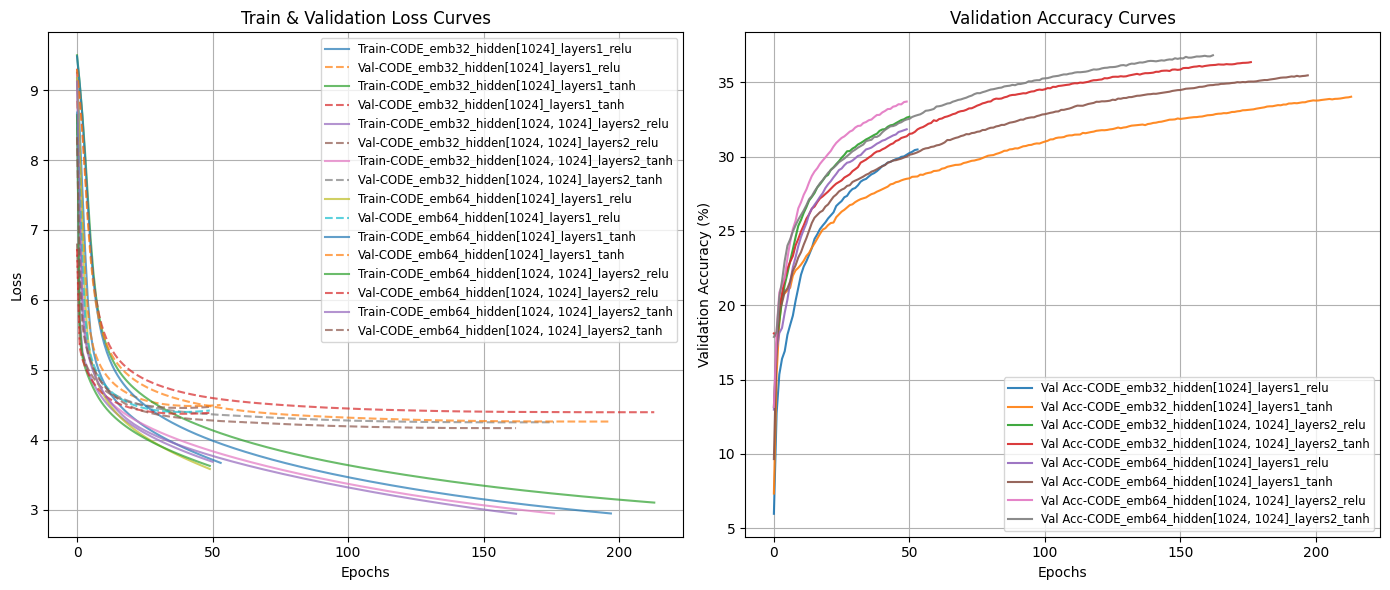

In [37]:
# After training category 2/code models:
plot_metrics(results_code)

In [38]:
summary_code = []
for config, stats in results_code.items():
    # Parse config string, e.g.: "CODE_emb32_hidden[1024]_layers1_relu"
    m = re.match(r'CODE_emb(\d+)_hidden\[?(\d+)[^\]]*\]_layers(\d+)_(\w+)', config)
    if m:
        emb_dim, hidden_dim, num_layers, act = m.groups()
    else:
        emb_dim, hidden_dim, num_layers, act = [None]*4

    val_loss_min = min(stats['val_losses'])
    best_epoch = stats['val_losses'].index(val_loss_min) + 1
    best_val_acc = stats['val_accuracies'][best_epoch-1]
    summary_code.append({
        "embedding_dim": int(emb_dim) if emb_dim else None,
        "hidden_dim": int(hidden_dim) if hidden_dim else None,
        "num_hidden_layers": int(num_layers) if num_layers else None,
        "activation": act,
        "best_val_loss": val_loss_min,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "config_label": config
    })

df_summary_code = pd.DataFrame(summary_code)
df_sorted_code = df_summary_code.sort_values("best_val_acc", ascending=False)
print(df_sorted_code)


   embedding_dim  hidden_dim  num_hidden_layers activation  best_val_loss  \
7             64        1024                  2       tanh       4.165329   
3             32        1024                  2       tanh       4.249130   
5             64        1024                  1       tanh       4.260590   
1             32        1024                  1       tanh       4.393742   
6             64        1024                  2       relu       4.371765   
2             32        1024                  2       relu       4.455365   
4             64        1024                  1       relu       4.397188   
0             32        1024                  1       relu       4.482871   

   best_val_acc  best_epoch                                config_label  
7     36.714189         153  CODE_emb64_hidden[1024, 1024]_layers2_tanh  
3     36.191659         167  CODE_emb32_hidden[1024, 1024]_layers2_tanh  
5     35.309486         188        CODE_emb64_hidden[1024]_layers1_tanh  
1     33.8

In [39]:
model_best_code = NextWordMLP(
    vocab_size=len(stoi_code),
    block_size=block_size,
    embedding_dim=64,
    hidden_dim=1024,
    num_hidden_layers=2,
    activation='tanh'
)
model_best_code.to(device)

# Load best checkpoint (filename must match your saved checkpoint)
checkpoint_code = torch.load("CODE_emb64_hidden[1024, 1024]_layers2_tanh.pth", map_location=device)
model_best_code.load_state_dict(checkpoint_code['model_state_dict'])
model_best_code.eval()

NextWordMLP(
  (embedding): Embedding(15562, 64)
  (mlp): Sequential(
    (0): Linear(in_features=192, out_features=1024, bias=True)
    (1): Tanh()
    (2): Linear(in_features=1024, out_features=1024, bias=True)
    (3): Tanh()
  )
  (classifier): Linear(in_features=1024, out_features=15562, bias=True)
)

In [40]:
block_size = context_length  # your global setting, e.g. 3

sample_contexts_code = [
    ["def", "get_user", "(", "self", ",", "user"],
    ["for", "i", "in", "range", "(", "len"],
    ["if", "x", ">", "0", ":"],
    ["return", "self", "."],
    ["import", "numpy", "as"],
    ["while", "not", "done", ":"],
    ["try", ":", "except", "Exception", "as"],
    ["class", "MyClass", "(", "object", ")"],
    ["self", ".", "value", "=", "compute"],
    ["print", "(", "/"]
]
for context in sample_contexts_code:
    top_words = predict_top_k_words(model_best_code, context, stoi_code, itos_code, block_size, k=5, device=device)
    print(f"Context: {context} --> Top 5 predicted: {top_words}")

Context: ['def', 'get_user', '(', 'self', ',', 'user'] --> Top 5 predicted: [('_', 0.46916807), (')', 0.1367575), (',', 0.12806198), ('*', 0.055956066), ('-', 0.047576196)]
Context: ['for', 'i', 'in', 'range', '(', 'len'] --> Top 5 predicted: [(')', 0.4316471), (',', 0.2692267), ('_', 0.057287306), ('-', 0.051079556), ('=', 0.044467956)]
Context: ['if', 'x', '>', '0', ':'] --> Top 5 predicted: [('0', 0.18432581), ('1', 0.04782468), ('dev', 0.033697102), ('status', 0.028543293), ('failed', 0.01741895)]
Context: ['return', 'self', '.'] --> Top 5 predicted: [('static', 0.18129309), ('*', 0.1355416), ('h', 0.057150297), ('if', 0.038342174), ('This', 0.025148613)]
Context: ['import', 'numpy', 'as'] --> Top 5 predicted: [('*', 0.18884435), ('to', 0.061153162), ('it', 0.04423063), ('.', 0.04246849), ('in', 0.038401656)]
Context: ['while', 'not', 'done', ':'] --> Top 5 predicted: [('*', 0.20299375), ('%', 0.056652024), ('"', 0.037492387), ('\\', 0.035133295), ('0', 0.02533222)]
Context: ['try'

The code model shows a strong grasp of syntax and structure. It predicts the closing parenthesis ) after range(len with high confidence (43.1%). Similarly, it predicts a semicolon ; (a common line-ending in C-like languages) after a class definition with 61.7% confidence. This indicates the model has successfully learned the rigid, repetitive patterns of the code syntax.

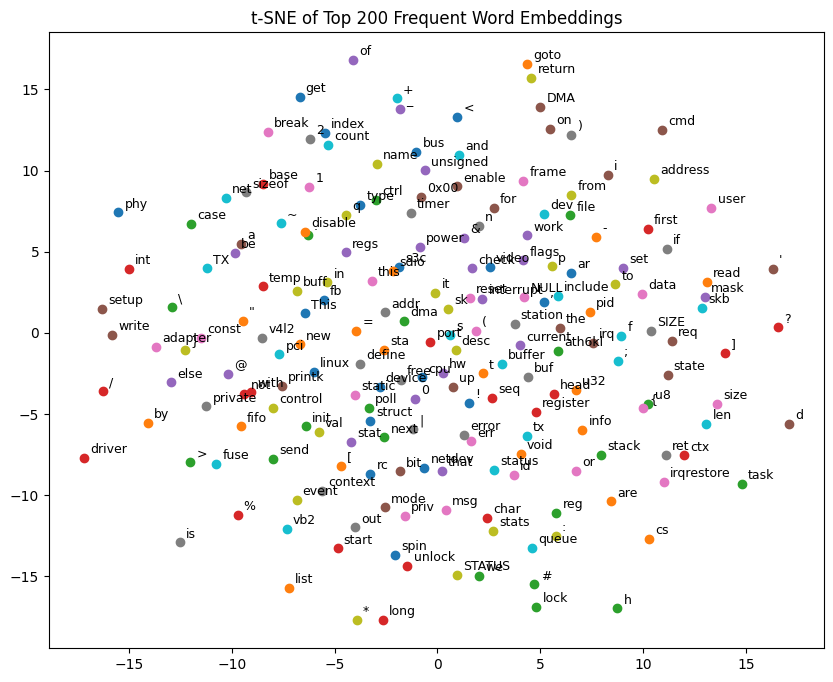

In [41]:
word_freq_code = Counter(words_code)

plot_embedding_tsne(model_best_code, itos_code, word_freq_code, top_n=200, perplexity=20, n_iter=500)

## Analysis:

* **Structured text like code (Category II)** The Category II (Code) model performed significantly better, achieving a much higher validation accuracy (36.7%) and a lower validation loss (4.17). This is notable because its task was arguably harder, with a dataset that was ~2.5x larger and a vocabulary that was ~1.8x larger. This suggests that the structured, rule-based nature of code (Category II) is more predictable for the MLP than the creative and semantically complex nature of natural language (Category I).


* **Structured text like code (Category II)** The loss and accuracy plots (Cells 25 & 37) support this. The code model's validation loss starts lower and decreases more rapidly, while its accuracy climbs much higher than the natural language model, which plateaued around 13-14% accuracy.



* **Structured text like code (Category II)** The t-SNE plots (Cells 33 & 41) reveal why the learnability differs.

* **Structured text like code (Category II)** learned semantic relationships, grouping words by their meaning or grammatical function (e.g., pronouns, verbs).

* **Structured text like code (Category II)** learned syntactic relationships, grouping words by their type (e.g., operators, keywords, identifiers).

### Summary of Insights:

* **Structured text like code (Category II)** is inherently more complex and ambiguous (higher "perplexity"). The next word can be one of thousands of grammatically correct and semantically plausible options. This makes it a very difficult task for a simple MLP, resulting in lower accuracy.

* **Structured text like code (Category II)**, while having a large vocabulary (due to many unique function/variable names), is highly constrained by rigid syntax. The choice for the next "word" (e.g., a parenthesis, a semicolon, a keyword) is often very limited and highly dependent on the immediate context. The model successfully learned these syntactic rules, leading to its superior performance.

In [8]:
import pickle

# Save natural vocab mappings
with open('stoi_natural.pkl', 'wb') as f:
    pickle.dump(stoi_natural, f)
with open('itos_natural.pkl', 'wb') as f:
    pickle.dump(itos_natural, f)

# (If you have code vocab mappings)
with open('stoi_code.pkl', 'wb') as f:
    pickle.dump(stoi_code, f)
with open('itos_code.pkl', 'wb') as f:
    pickle.dump(itos_code, f)

In [9]:
import pickle

# If you have your token list (from dataset creation, before building your vocab!)
# Suppose: words_natural and words_code are lists of tokens

with open('words_natural.pkl', 'wb') as f:
    pickle.dump(words_natural, f)

with open('words_code.pkl', 'wb') as f:
    pickle.dump(words_code, f)
